# BGL Anomaly Detection: Hybrid RAG (BM25 + Dense) — Logs KB Only

**Experiment:** E13-B — Hybrid RAG using only the `bgl_logs` Qdrant collection.
**Strategy:** For each test log, BM25 sparse retrieval and Qdrant dense retrieval
are both run against the `bgl_logs` collection. The two ranked lists are fused
via Reciprocal Rank Fusion (RRF, k=60) and the top-K merged results are injected
into the LLM prompt. No system architecture, severity taxonomy, RCA examples,
or role guides are retrieved.
**Purpose:** Ablation — isolates the contribution of hybrid log-similarity
retrieval alone, without any supplementary domain knowledge.
**References:** E05 (Hybrid RAG full multi-collection), E13-A (Vanilla RAG Logs Only).
**Dataset:** BGL (Blue Gene/L), 2k sample — same 215-entry held-out test set as all other experiments.


In [1]:
# =============================================================================
# CELL 1 — PACKAGE INSTALLATION
# =============================================================================
import subprocess, sys

def install_packages(pkgs):
    for p in pkgs:
        print(f"Installing: {p}")
        r = subprocess.run(
            [sys.executable, "-m", "pip", "install", p, "-q"],
            capture_output=True, text=True,
        )
        print("  OK" if r.returncode == 0 else f"  WARN: {r.stderr[:120]}")

install_packages([
    "pandas", "numpy", "scikit-learn", "matplotlib", "seaborn",
    "groq", "tqdm", "sentence-transformers", "qdrant-client", "rank-bm25",
])
print("\nAll packages ready.")


Installing: pandas
  OK
Installing: numpy
  OK
Installing: scikit-learn
  OK
Installing: matplotlib
  OK
Installing: seaborn
  OK
Installing: groq
  OK
Installing: tqdm
  OK
Installing: sentence-transformers
  OK
Installing: qdrant-client
  OK
Installing: rank-bm25
  OK

All packages ready.


Prompts loaded from : c:\Users\Abhishek Mulay\Desktop\UpgradAIML\Masters\Topics\Revised_Topics\Topic 1\LogSense\Implementation\Experiments\src\Prompts
  Dataset               : BGL
  Experiment            : Hybrid RAG (BM25+Dense, Logs Only)
  Embed model           : BAAI/bge-base-en-v1.5
  LLM model             : llama-3.1-8b-instant
  Eval model            : qwen/qwen3-32b
  Test normal cap       : 200
  Test anomaly cap      : 15
  Retrieval K (BM25+Dense, bgl_logs only) : 5  [RRF k=60]
  Primary Groq keys     : 5  | Fallback keys: 5

Loading BGL structured log ...
  Rows: 2000,  Normal: 1857,  Anomalous: 143

Creating test split ...
  Test Normal     : 200  (93.0%)
  Test Anomalous  : 15  (7.0%)
  Test Total      : 215

Connecting to persistent Qdrant KB ...
Collection                Points
----------------------------------
bgl_logs                    3765
bgl_architecture             402
bgl_severity                  80
bgl_rca                       75
hdfs_logs                  

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4427.52it/s]
BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Log hits (1) [BM25+Dense RRF]:
    [1] Anomalous  rrf=0.0286  [KERNEL] [FATAL] data TLB error interrupt | Template: data TLB er
  Parallel workers : 5
  Primary keys     : 5  | Fallback keys: 5

Running parallel Hybrid RAG (BM25+Dense, Logs Only) inference on 215 test samples ...
  Retrieval K (BM25+Dense RRF, bgl_logs only) : 5  [RRF k=60]
  LLM model                                    : llama-3.1-8b-instant
  Workers                                      : 5



Hybrid RAG (BM25+Dense, Logs Only) Inference: 100%|██████████| 215/215 [06:27<00:00,  1.80s/it]



  Inference complete.  Parse errors: 0 / 215

  EFFICIENCY SUMMARY  [BGL]  Hybrid RAG (BM25+Dense, Logs Only)  (n=215)
  Metric                 Retrieval (ms)   LLM Latency (ms)   Generation (ms)    Total (ms)
----------------------------------------------------------------------------------------
  Mean                            222.7             7367.7             649.2        8239.5
  Median                          189.2             7623.5             183.9        8532.3
  p95                             451.4            12168.9            3110.4       13289.7
  p99                             614.4            18059.1            3574.0       18703.4
  Min                             108.8              195.1               3.7         353.8
  Max                             867.2            23571.8            5273.0       24629.4

  STANDARD METRICS  [BGL]  (Hybrid RAG (BM25+Dense, Logs Only))
  Test set  : 215  (Normal=200, Anomalous=15)
  TP=15  TN=169  FP=31  FN=0
--------------

...

  [rate-limit] Worker rotated to fallback key (attempt 1/9)


RAG Evaluation:  87%|████████▋ | 13/15 [10:37<01:33, 46.69s/it]

  [rate-limit] All keys exhausted — sleeping 60s (attempt 1/9)


RAG Evaluation: 100%|██████████| 15/15 [12:44<00:00, 51.00s/it]



  RETRIEVAL METRICS  [BGL]  (n=15)
  MRR                   : 1.0000
  Hit Rate @5           : 1.0000
  Context Precision     : 1.0000

  RAGAs METRICS
  Faithfulness          : 0.6733
  Answer Relevance      : 0.8733
  Context Precision     : 1.0000
  Context Recall        : 0.2967

  ADDITIONAL RAG METRICS
  Root Cause Score      : 0.9200
  Evidence Support      : 0.9667
  Severity Agreement    : 1.0000
  Consistency Score     : 1.0000
  Role Appr. (SRE)      : 0.6600
  Role Appr. (DevOps)   : 0.6400
  Completeness Score    : 0.9467


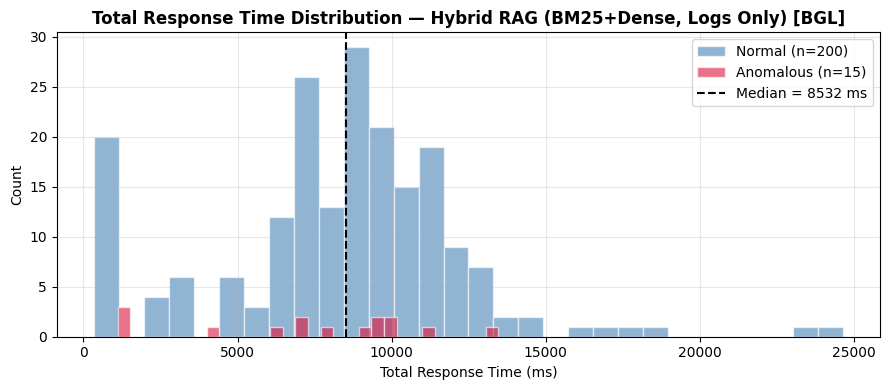

  Saved: bgl_hybrid_logs_only_rag_response_time_dist.png


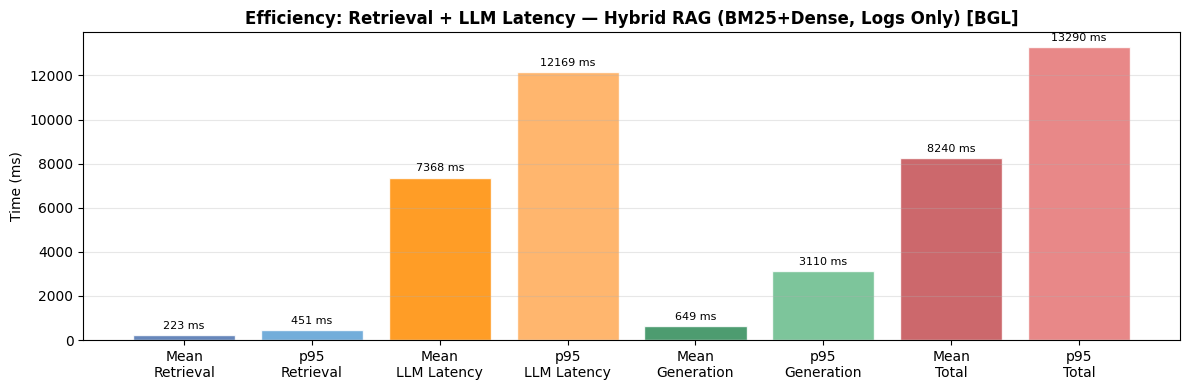

  Saved: bgl_hybrid_logs_only_rag_latency_breakdown.png


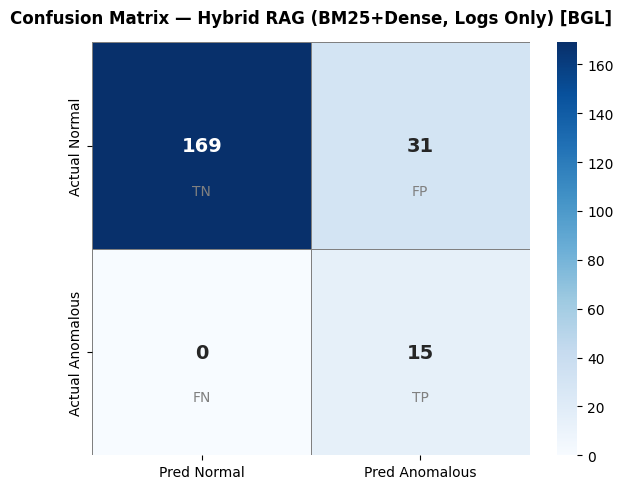

  Saved: bgl_hybrid_logs_only_rag_confusion_matrix.png


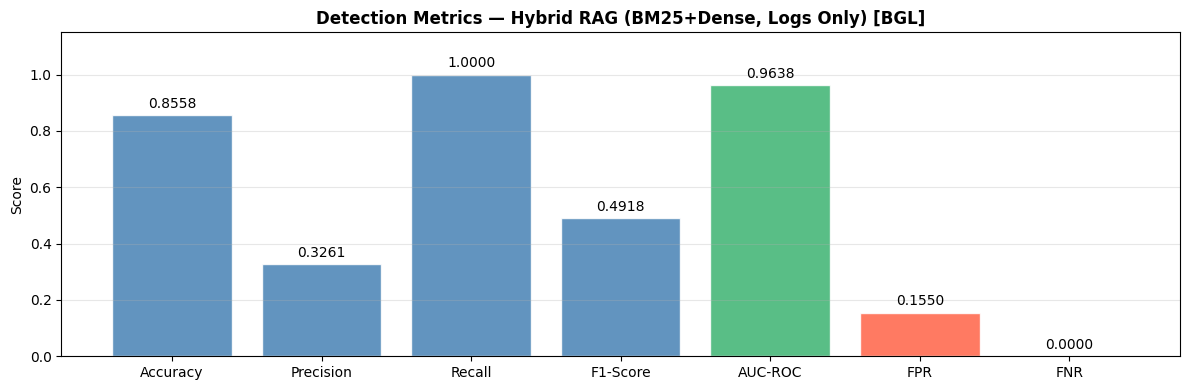

  Saved: bgl_hybrid_logs_only_rag_detection_metrics.png


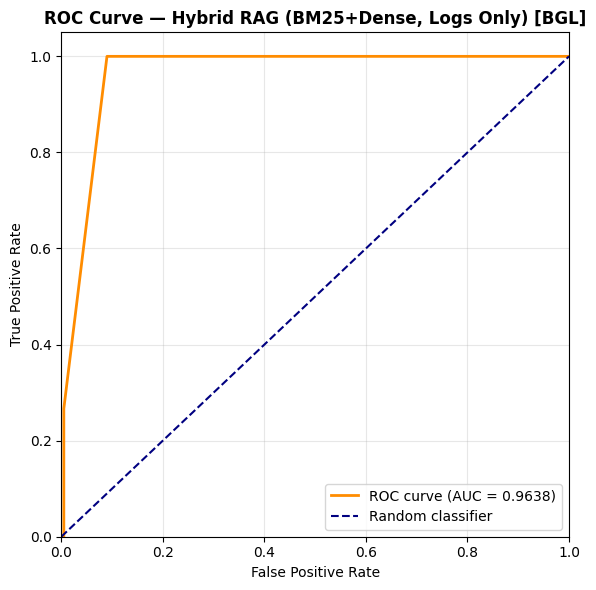

  Saved: bgl_hybrid_logs_only_rag_roc_curve.png


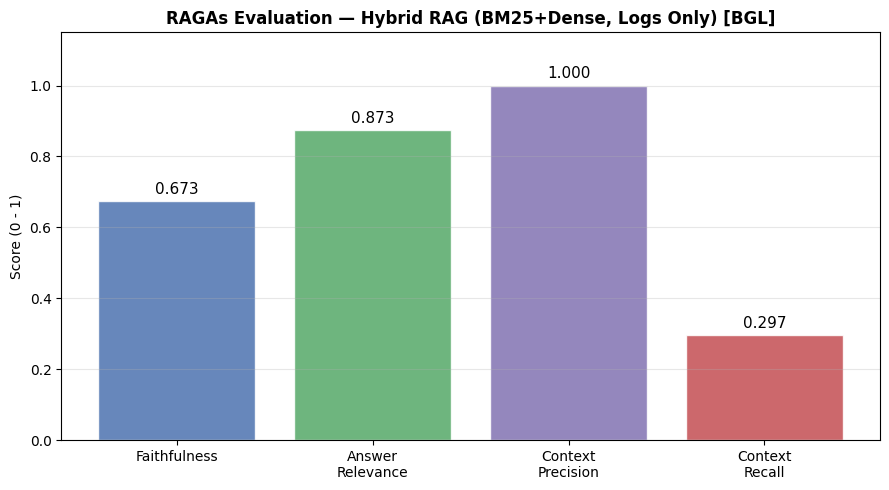

  Saved: bgl_hybrid_logs_only_rag_ragas_metrics.png


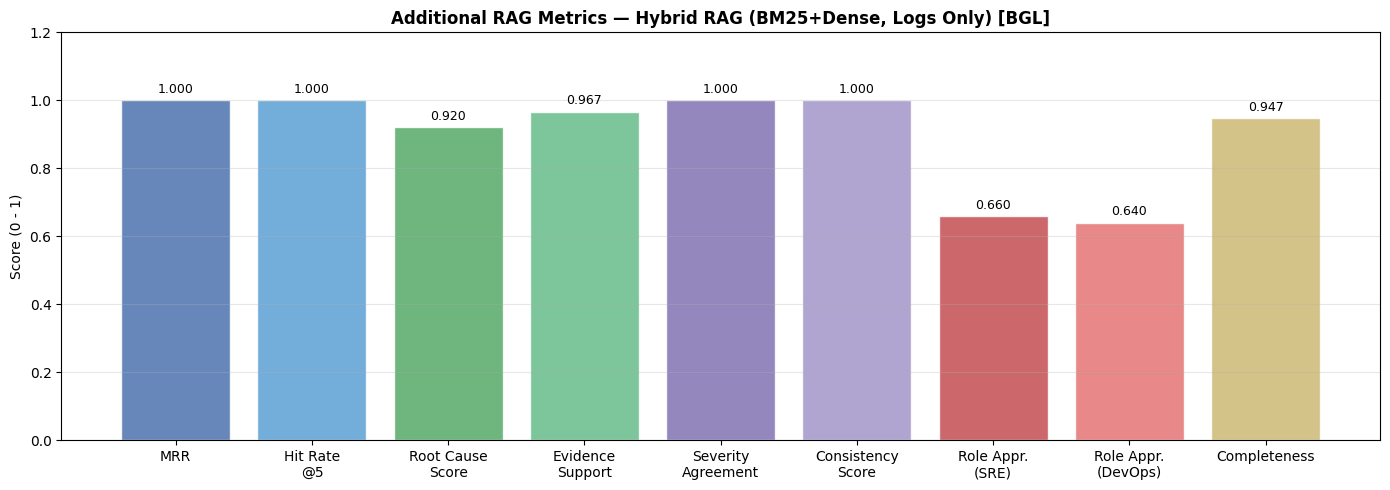

  Saved: bgl_hybrid_logs_only_rag_additional_rag_metrics.png


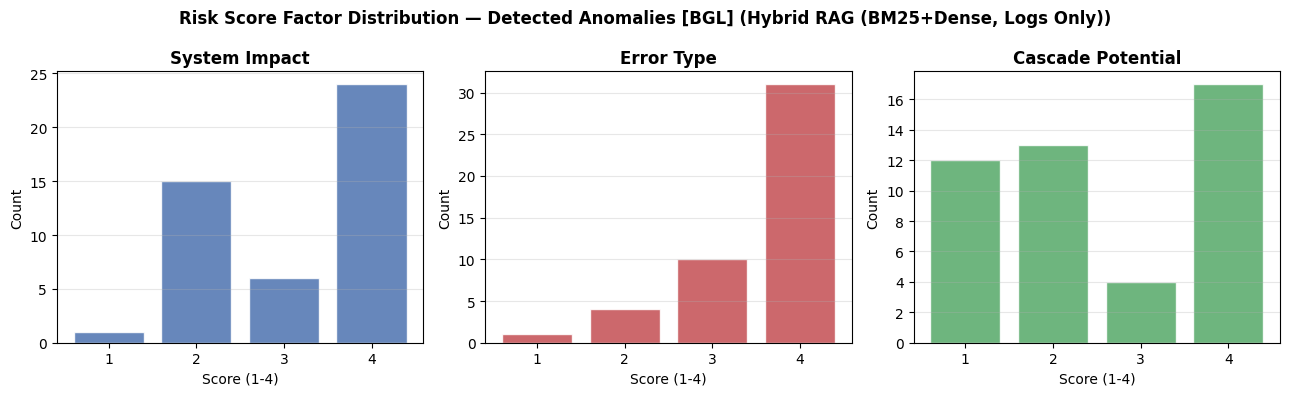

  Saved: bgl_hybrid_logs_only_rag_risk_score_dist.png

All visualisations complete.


In [2]:
# =============================================================================
# CELL 2 — IMPORTS, CONFIGURATION, DATA LOADING, KB,
#           BM25 INDEX, HYBRID RETRIEVAL (LOGS ONLY), INFERENCE, METRICS, VIZ
# =============================================================================

# -- Standard library imports -------------------------------------------------
import json, os, re, sys, time, warnings
from typing import Any, Dict, List, Optional, Tuple

# -- Third-party imports ------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from groq import Groq
from rank_bm25 import BM25Okapi
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score, roc_curve,
)
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore")

# -- Persistent KB (src/KnowledgeBase/) ---------------------------------------
_KB_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "KnowledgeBase"))
if _KB_DIR not in sys.path:
    sys.path.insert(0, _KB_DIR)
from kb_utils import KBClient

# -- Shared prompt repository (src/Prompts/) ----------------------------------
_PROMPTS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "Prompts"))
if _PROMPTS_DIR not in sys.path:
    sys.path.insert(0, _PROMPTS_DIR)

from detection_prompts import (
    BGL_CONFIG,
    build_rag_system_prompt,
    format_retrieved_context,
)
from eval_prompts import (
    JUDGE_SYSTEM_PROMPT,
    build_faithfulness_prompt,
    build_answer_relevance_prompt,
    build_sre_appropriateness_prompt,
    build_devops_appropriateness_prompt,
    build_context_recall_prompt,
    build_root_cause_score_prompt,
    build_evidence_support_prompt,
    build_completeness_prompt_rag,
)
print(f"Prompts loaded from : {_PROMPTS_DIR}")
RAG_SYSTEM_PROMPT = build_rag_system_prompt(BGL_CONFIG)

# =============================================================================
# SECTION 1 — CONFIGURATION
# =============================================================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATASET          = "BGL"
EXPERIMENT_LABEL = "Hybrid RAG (BM25+Dense, Logs Only)"
PREFIX           = "bgl_hybrid_logs_only_rag"

EMBED_MODEL_NAME = "BAAI/bge-base-en-v1.5"
LLM_MODEL        = "llama-3.1-8b-instant"
EVAL_MODEL       = "qwen/qwen3-32b"

N_FEW_SHOT_NORMAL = 5
N_FEW_SHOT_ANOM   = 5

TEST_NORMAL_CAP  = 200
TEST_ANOMALY_CAP = 15

# Retrieval — bgl_logs collection only, BM25 + Dense fused by RRF
RETRIEVAL_K = 5
RRF_K       = 60   # RRF smoothing constant: rrf(d) = sum_i 1/(RRF_K + rank_i)

MAX_RETRIES     = 3
RETRY_DELAY_S   = 5
REQUEST_DELAY_S = 0.5
LLM_MAX_TOKENS  = 900
LLM_TEMPERATURE = 0.0
EVAL_MAX_TOKENS = 1024   # qwen3 emits <think>...</think> before JSON

def _load_groq_key(n: int) -> Optional[str]:
    p = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "Keys", f"groq_key_{n}.txt"))
    try:
        with open(p) as _f:
            return _f.read().strip()
    except FileNotFoundError:
        return None

_ALL_PRIMARY  = [k for k in [_load_groq_key(i) for i in range(1, 6)]  if k]
_ALL_FALLBACK = [k for k in [_load_groq_key(i) for i in range(6, 11)] if k]

if not _ALL_PRIMARY:
    raise FileNotFoundError(
        "No primary Groq keys found. "
        "Expected src/Keys/groq_key_1.txt – groq_key_5.txt"
    )

GROQ_API_KEY = _ALL_PRIMARY[0]

DATASET_CONFIG = {
    "structured_log_path": "../../../Datasets/BGL/Processed/BGL_2k.log_structured.csv",
    "templates_path":      "../../../Datasets/BGL/Processed/BGL_2k.log_templates.csv",
    "label_col":     "Label",
    "normal_value":  "-",
    "event_id_col":  "EventId",
    "component_col": "Component",
    "level_col":     "Level",
    "content_col":   "Content",
    "template_col":  "EventTemplate",
}

print(f"  Dataset               : {DATASET}")
print(f"  Experiment            : {EXPERIMENT_LABEL}")
print(f"  Embed model           : {EMBED_MODEL_NAME}")
print(f"  LLM model             : {LLM_MODEL}")
print(f"  Eval model            : {EVAL_MODEL}")
print(f"  Test normal cap       : {TEST_NORMAL_CAP}")
print(f"  Test anomaly cap      : {TEST_ANOMALY_CAP}")
print(f"  Retrieval K (BM25+Dense, bgl_logs only) : {RETRIEVAL_K}  [RRF k={RRF_K}]")
print(f"  Primary Groq keys     : {len(_ALL_PRIMARY)}  | Fallback keys: {len(_ALL_FALLBACK)}")

# =============================================================================
# SECTION 2 — DATA LOADING
# =============================================================================
def build_log_text(row: pd.Series) -> str:
    comp = str(row.get("Component", "")).strip()
    lvl  = str(row.get("Level", "")).strip()
    cont = str(row.get("Content", "")).strip()
    tmpl = str(row.get("EventTemplate", "")).strip()
    return f"[{comp}] [{lvl}] {cont} | Template: {tmpl}"

def load_bgl(config: Dict) -> pd.DataFrame:
    print("\nLoading BGL structured log ...")
    df_logs = pd.read_csv(config["structured_log_path"])
    df_tmpl = pd.read_csv(config["templates_path"])
    df = df_logs.merge(df_tmpl, on=config["event_id_col"], how="left", suffixes=("", "_tmpl"))
    df["is_normal"]    = df[config["label_col"]] == config["normal_value"]
    df["binary_label"] = (~df["is_normal"]).astype(int)
    df["log_text"]     = df.apply(build_log_text, axis=1)
    n_norm = int(df["is_normal"].sum())
    n_anom = int((~df["is_normal"]).sum())
    print(f"  Rows: {len(df)},  Normal: {n_norm},  Anomalous: {n_anom}")
    return df

df = load_bgl(DATASET_CONFIG)

# =============================================================================
# SECTION 3 — TEST SPLIT
#
# Mirrors the exact split used in build_kb.py and all other experiments.
# =============================================================================
def create_test_split(
    df: pd.DataFrame,
    n_few_shot_normal: int,
    n_few_shot_anom: int,
    test_normal_cap: int,
    test_anomaly_cap: int,
    seed: int = 42,
) -> pd.DataFrame:
    df_n = df[df["is_normal"]].sample(frac=1, random_state=seed).reset_index(drop=True)
    df_a = df[~df["is_normal"]].sample(frac=1, random_state=seed).reset_index(drop=True)
    rem_n = df_n.iloc[n_few_shot_normal:].reset_index(drop=True)
    rem_a = df_a.iloc[n_few_shot_anom:].reset_index(drop=True)
    n_t_n = min(test_normal_cap,  len(rem_n))
    n_t_a = min(test_anomaly_cap, len(rem_a))
    if n_t_a < test_anomaly_cap:
        print(f"  WARNING: only {n_t_a} anomalies available (requested {test_anomaly_cap}).")
    return (
        pd.concat([rem_n.iloc[:n_t_n], rem_a.iloc[:n_t_a]], ignore_index=True)
        .sample(frac=1, random_state=seed).reset_index(drop=True)
    )

print("\nCreating test split ...")
test_df = create_test_split(
    df, N_FEW_SHOT_NORMAL, N_FEW_SHOT_ANOM,
    TEST_NORMAL_CAP, TEST_ANOMALY_CAP, RANDOM_SEED,
)
n_tn = int(test_df["is_normal"].sum())
n_ta = int((~test_df["is_normal"]).sum())
print(f"  Test Normal     : {n_tn}  ({n_tn/len(test_df)*100:.1f}%)")
print(f"  Test Anomalous  : {n_ta}  ({n_ta/len(test_df)*100:.1f}%)")
print(f"  Test Total      : {len(test_df)}")

# =============================================================================
# SECTION 4 — PERSISTENT KNOWLEDGE BASE CLIENT
# =============================================================================
print("\nConnecting to persistent Qdrant KB ...")
kb = KBClient()
kb.collection_stats()
print("  KB client ready")

# =============================================================================
# SECTION 4b — BM25 SPARSE INDEX (bgl_logs corpus)
#
# All bgl_logs KB entries are loaded via Qdrant scroll and tokenised to build
# a BM25Okapi index.  Used alongside Qdrant dense retrieval in retrieve(),
# with Reciprocal Rank Fusion (RRF) merging both ranked lists.
# =============================================================================
print("\nBuilding BM25 index from bgl_logs KB corpus ...")
_bm25_corpus: List[Dict] = []
_scroll_offset = None
while True:
    _pts, _scroll_offset = kb._client.scroll(
        "bgl_logs",
        offset=_scroll_offset,
        limit=200,
        with_payload=True,
        with_vectors=False,
    )
    for pt in _pts:
        lbl = pt.payload.get("label", "Normal")
        _bm25_corpus.append({
            "text":         pt.payload.get("text", ""),
            "label":        lbl,
            "binary_label": 0 if lbl == "Normal" else 1,
        })
    if _scroll_offset is None:
        break

_bm25_tokens = [
    re.sub("[^a-z0-9 ]", " ", doc["text"].lower()).split()
    for doc in _bm25_corpus
]
_bm25_index = BM25Okapi(_bm25_tokens)
print(f"  BM25 index built: {len(_bm25_corpus)} log entries")

# =============================================================================
# SECTION 5 — HYBRID RETRIEVAL (BM25 + DENSE → RRF, bgl_logs only)
#
# Only the bgl_logs collection is used — no system architecture,
# severity taxonomy, RCA examples, or role guides.
#
# RRF formula: rrf(d) = sum_i  1 / (RRF_K + rank_i(d))
# Documents absent from one list get no contribution from that list.
#
# Ablation purpose: measure the contribution of hybrid retrieval alone
# (BM25 keyword matching + dense semantic similarity) restricted to
# log examples, without any supplementary domain knowledge.
# =============================================================================

def _build_user_prompt(log_text: str, log_hits: List[Dict]) -> str:
    log_ctx = format_retrieved_context(log_hits) if log_hits else "(none)"
    return (
        f"Log entry to analyze:\n{log_text}\n\n"
        f"Similar log examples from knowledge base (BM25+Dense hybrid):\n{log_ctx}"
    )


def retrieve(query_text: str) -> List[Dict]:
    top_k_pool = RETRIEVAL_K * 2

    # Qdrant dense retrieval — bgl_logs only
    raw_dense = kb.query_bgl_logs(query_text, top_k=top_k_pool)

    # BM25 sparse retrieval — same bgl_logs corpus
    bm25_q   = re.sub("[^a-z0-9 ]", " ", query_text.lower()).split()
    bm25_raw = _bm25_index.get_scores(bm25_q)
    bm25_top = sorted(
        range(len(_bm25_corpus)),
        key=lambda i: bm25_raw[i],
        reverse=True,
    )[:top_k_pool]

    # Union candidate pool keyed by text
    candidates: Dict[str, Dict] = {}
    for rank, h in enumerate(raw_dense, start=1):
        txt = h["text"]
        candidates[txt] = {
            "text":         txt,
            "label":        h.get("label", "Normal"),
            "binary_label": 0 if h.get("label") == "Normal" else 1,
            "dense_rank":   rank,
            "bm25_rank":    None,
        }
    for rank, idx in enumerate(bm25_top, start=1):
        txt = _bm25_corpus[idx]["text"]
        if txt in candidates:
            candidates[txt]["bm25_rank"] = rank
        else:
            candidates[txt] = {
                "text":         txt,
                "label":        _bm25_corpus[idx]["label"],
                "binary_label": _bm25_corpus[idx]["binary_label"],
                "dense_rank":   None,
                "bm25_rank":    rank,
            }

    def _rrf(c: Dict) -> float:
        s = 0.0
        if c["dense_rank"] is not None:
            s += 1.0 / (RRF_K + c["dense_rank"])
        if c["bm25_rank"] is not None:
            s += 1.0 / (RRF_K + c["bm25_rank"])
        return s

    fused = sorted(candidates.values(), key=_rrf, reverse=True)[:RETRIEVAL_K]

    return [
        {
            "log_text":     c["text"],
            "label":        c["label"],
            "binary_label": c["binary_label"],
            "score":        round(_rrf(c), 4),
            "rank":         pos + 1,
        }
        for pos, c in enumerate(fused)
    ]


# Sanity check
print(f"\nRetrieval sanity check  (bgl_logs BM25+Dense RRF, k={RETRIEVAL_K}) ...")
_q = test_df.iloc[0]["log_text"]
print(f"  Query : {_q[:90]}")
_log_hits = retrieve(_q)
print(f"\n  Log hits ({len(_log_hits)}) [BM25+Dense RRF]:")
for r in _log_hits:
    print(f"    [{r['rank']}] {r['label']:9s}  rrf={r['score']:.4f}  {r['log_text'][:65]}")

# =============================================================================
# SECTION 7 — GROQ CLIENT AND API HELPERS
# =============================================================================
import threading

N_PARALLEL_WORKERS = min(5, len(_ALL_PRIMARY))

_fallback_lock = threading.Lock()
_fallback_pool = list(_ALL_FALLBACK)

_worker_key  = threading.local()
_assign_lock = threading.Lock()
_assign_idx  = [0]


def _init_worker_key() -> None:
    if not hasattr(_worker_key, "current"):
        with _assign_lock:
            idx     = _assign_idx[0] % len(_ALL_PRIMARY)
            stagger = _assign_idx[0]
            _assign_idx[0] += 1
        time.sleep(stagger * 1.0)
        _worker_key.current = _ALL_PRIMARY[idx]


def _rotate_to_fallback() -> bool:
    with _fallback_lock:
        if _fallback_pool:
            _worker_key.current = _fallback_pool.pop(0)
            return True
    return False


def _is_rate_limit(exc: Exception) -> bool:
    s = type(exc).__name__ + " " + str(exc)
    return "ratelimit" in s.lower() or "rate_limit" in s.lower() or "429" in s

print(f"  Parallel workers : {N_PARALLEL_WORKERS}")
print(f"  Primary keys     : {len(_ALL_PRIMARY)}  | Fallback keys: {len(_ALL_FALLBACK)}")


def call_groq(
    system_prompt: str,
    user_message: str,
    model: str,
    max_tokens: int = LLM_MAX_TOKENS,
    temperature: float = LLM_TEMPERATURE,
) -> Tuple[Optional[str], float, float]:
    _init_worker_key()
    budget = MAX_RETRIES + len(_ALL_FALLBACK) + 1
    for attempt in range(budget):
        try:
            client = Groq(api_key=_worker_key.current)
            t0     = time.perf_counter()
            resp   = client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user",   "content": user_message},
                ],
                max_tokens=max_tokens,
                temperature=temperature,
            )
            t1    = time.perf_counter()
            total = (t1 - t0) * 1000.0
            usage = resp.usage
            c_tok = usage.completion_tokens if usage else 1
            p_tok = usage.prompt_tokens     if usage else 0
            gen_ms = total * (c_tok / ((p_tok + c_tok) or 1))
            return resp.choices[0].message.content.strip(), total - gen_ms, gen_ms
        except Exception as e:
            if _is_rate_limit(e):
                if _rotate_to_fallback():
                    print(f"  [rate-limit] Worker rotated to fallback key (attempt {attempt+1}/{budget})", flush=True)
                    continue
                print(f"  [rate-limit] All keys exhausted — sleeping 60s (attempt {attempt+1}/{budget})", flush=True)
                time.sleep(60)
            else:
                time.sleep(RETRY_DELAY_S * min(attempt + 1, 5))
    print(f"  [call-groq] All {budget} attempts failed — returning None", flush=True)
    return None, 0.0, 0.0


def _strip_thinking(raw: str) -> str:
    stripped = re.sub(r'<think>.*?</think>', '', raw, flags=re.DOTALL).strip()
    return stripped if stripped else raw

# =============================================================================
# SECTION 8 — RESPONSE PARSER
#
# Risk Score formula (applied programmatically — not trusted from LLM output):
#   total = (system_impact x 0.4) + (error_type x 0.3) + (cascade_potential x 0.2)
# =============================================================================
def _compute_risk(si: Any, et: Any, cp: Any) -> Dict:
    si  = max(1, min(4, int(si)))
    et  = max(1, min(4, int(et)))
    cp  = max(1, min(4, int(cp)))
    tot = round(si * 0.4 + et * 0.3 + cp * 0.2, 3)
    lvl = "High" if tot >= 2.8 else ("Medium" if tot >= 1.8 else "Low")
    return {"system_impact": si, "error_type": et, "cascade_potential": cp,
            "total_score": tot, "risk_level": lvl}

def parse_rag_response(raw: Optional[str]) -> Dict:
    default = {
        "label": "Normal", "confidence": 0.5, "anomaly_explanation": "",
        "rca_summary": "", "rca_detailed": "", "rca_confidence_level": "",
        "rca_confidence_reasoning": "", "rca_causal_chain": [],
        "rca_supporting_evidence": [],
        "risk_system_impact": 0, "risk_error_type": 0, "risk_cascade_potential": 0,
        "risk_total_score": 0.0, "risk_level": "",
        "sre_action": "", "devops_action": "", "parse_error": True,
    }
    if raw is None:
        return default.copy()
    try:
        cleaned = re.sub(r"```(?:json)?\s*", "", raw).strip().rstrip("`")
        m = re.search(r'\{.*\}', cleaned, re.DOTALL)
        if m:
            p = json.loads(m.group())
            r = default.copy()
            r["parse_error"] = False
            r["label"]       = str(p.get("label", "Normal"))
            r["confidence"]  = float(max(0.0, min(1.0, float(p.get("confidence", 0.5)))))
            if r["label"] == "Anomalous":
                r["anomaly_explanation"]       = str(p.get("anomaly_explanation", ""))
                rca = p.get("rca", {})
                r["rca_summary"]               = str(rca.get("summary", ""))
                r["rca_detailed"]              = str(rca.get("detailed_description", ""))
                r["rca_confidence_level"]      = str(rca.get("confidence_level", ""))
                r["rca_confidence_reasoning"]  = str(rca.get("confidence_reasoning", ""))
                r["rca_causal_chain"]          = list(rca.get("causal_chain", []))
                r["rca_supporting_evidence"]   = list(rca.get("supporting_evidence", []))
                rs  = p.get("risk_score", {})
                crs = _compute_risk(
                    rs.get("system_impact", 2),
                    rs.get("error_type", 2),
                    rs.get("cascade_potential", 2),
                )
                r["risk_system_impact"]     = crs["system_impact"]
                r["risk_error_type"]        = crs["error_type"]
                r["risk_cascade_potential"] = crs["cascade_potential"]
                r["risk_total_score"]       = crs["total_score"]
                r["risk_level"]             = crs["risk_level"]
                rem = p.get("remediation", {})
                r["sre_action"]    = str(rem.get("sre_action", ""))
                r["devops_action"] = str(rem.get("devops_action", ""))
            return r
    except (json.JSONDecodeError, ValueError, TypeError):
        pass
    return default.copy()

# =============================================================================
# SECTION 9 — RAG INFERENCE ON TEST SET (BM25+Dense, bgl_logs only)
# =============================================================================
print(f"\nRunning parallel {EXPERIMENT_LABEL} inference on {len(test_df)} test samples ...")
print(f"  Retrieval K (BM25+Dense RRF, bgl_logs only) : {RETRIEVAL_K}  [RRF k={RRF_K}]")
print(f"  LLM model                                    : {LLM_MODEL}")
print(f"  Workers                                      : {N_PARALLEL_WORKERS}\n")


def _run_rag_inference(row_dict: dict) -> dict:
    t_ret0   = time.perf_counter()
    log_hits = retrieve(row_dict["log_text"])
    ret_ms   = (time.perf_counter() - t_ret0) * 1000.0
    raw, l_ms, g_ms = call_groq(
        RAG_SYSTEM_PROMPT,
        _build_user_prompt(row_dict["log_text"], log_hits),
        LLM_MODEL,
    )
    parsed                   = parse_rag_response(raw)
    parsed["true_label"]     = int(row_dict["binary_label"])
    parsed["log_text"]       = row_dict["log_text"]
    parsed["raw_response"]   = raw
    parsed["retrieved_docs"] = log_hits   # label-based metrics
    parsed["knowledge_docs"] = []         # no supplementary knowledge retrieved
    parsed["retrieval_ms"]   = ret_ms
    parsed["latency_ms"]     = l_ms
    parsed["generation_ms"]  = g_ms
    return parsed


rows    = test_df.to_dict("records")
results: List[Dict] = [None] * len(rows)

with ThreadPoolExecutor(max_workers=N_PARALLEL_WORKERS) as executor:
    future_to_idx = {
        executor.submit(_run_rag_inference, row): idx
        for idx, row in enumerate(rows)
    }
    for future in tqdm(as_completed(future_to_idx), total=len(rows),
                       desc=f"{EXPERIMENT_LABEL} Inference"):
        idx = future_to_idx[future]
        try:
            results[idx] = future.result()
        except Exception as exc:
            print(f"  Worker error on row {idx}: {exc}")
            results[idx] = {
                "true_label": int(rows[idx]["binary_label"]),
                "log_text": rows[idx]["log_text"],
                "label": "Normal", "confidence": 0.5,
                "parse_error": True, "raw_response": None,
                "retrieved_docs": [], "knowledge_docs": [],
                "retrieval_ms": 0.0, "latency_ms": 0.0, "generation_ms": 0.0,
            }

results_df = pd.DataFrame(results)
results_df["pred_label"] = results_df["label"].apply(
    lambda x: 1 if str(x).strip().lower() == "anomalous" else 0
)
print(f"\n  Inference complete.  Parse errors: {int(results_df['parse_error'].sum())} / {len(results_df)}")

# =============================================================================
# SECTION 10 — EFFICIENCY SUMMARY
# =============================================================================
ret_arr = results_df["retrieval_ms"].values
lat_arr = results_df["latency_ms"].values
gen_arr = results_df["generation_ms"].values
tot_arr = ret_arr + lat_arr + gen_arr

print("\n" + "=" * 82)
print(f"  EFFICIENCY SUMMARY  [{DATASET}]  {EXPERIMENT_LABEL}  (n={len(results_df)})")
print("=" * 82)
print(f"  {'Metric':<20}  {'Retrieval (ms)':>15}  {'LLM Latency (ms)':>17}  "
      f"{'Generation (ms)':>16}  {'Total (ms)':>12}")
print("-" * 88)
_stat_fns = {
    "Mean":   np.mean, "Median": np.median,
    "p95":    lambda x: np.percentile(x, 95),
    "p99":    lambda x: np.percentile(x, 99),
    "Min":    np.min,  "Max":    np.max,
}
for lbl, fn in _stat_fns.items():
    print(f"  {lbl:<20}  {fn(ret_arr):>15.1f}  {fn(lat_arr):>17.1f}  "
          f"{fn(gen_arr):>16.1f}  {fn(tot_arr):>12.1f}")
print("=" * 82)

latency_summary = {
    "mean_retrieval_ms":  float(ret_arr.mean()),
    "p95_retrieval_ms":   float(np.percentile(ret_arr, 95)),
    "mean_latency_ms":    float(lat_arr.mean()),
    "p95_latency_ms":     float(np.percentile(lat_arr, 95)),
    "mean_generation_ms": float(gen_arr.mean()),
    "p95_generation_ms":  float(np.percentile(gen_arr, 95)),
    "mean_total_ms":      float(tot_arr.mean()),
    "p95_total_ms":       float(np.percentile(tot_arr, 95)),
}

# =============================================================================
# SECTION 11 — STANDARD ANOMALY DETECTION METRICS
# =============================================================================
y_true   = results_df["true_label"].tolist()
y_pred   = results_df["pred_label"].tolist()
y_scores = [
    c if lbl == "Anomalous" else 1.0 - c
    for c, lbl in zip(results_df["confidence"], results_df["label"])
]

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
rec  = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
f1   = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
cm   = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0.0
fnr_val = fn / (fn + tp) if (fn + tp) > 0 else 0.0
try:
    auc = roc_auc_score(y_true, y_scores)
except ValueError:
    auc = float("nan")
fpr_curve, tpr_curve, _ = roc_curve(y_true, y_scores)

n_pos, n_neg = y_true.count(1), y_true.count(0)
print("\n" + "=" * 64)
print(f"  STANDARD METRICS  [{DATASET}]  ({EXPERIMENT_LABEL})")
print("=" * 64)
print(f"  Test set  : {len(y_true)}  (Normal={n_neg}, Anomalous={n_pos})")
print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
print("-" * 64)
print(f"  Accuracy   : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision  : {prec:.4f}")
print(f"  Recall     : {rec:.4f}")
print(f"  F1-Score   : {f1:.4f}")
print(f"  FPR        : {fpr_val:.4f}")
print(f"  FNR        : {fnr_val:.4f}")
print(f"  AUC-ROC    : {auc:.4f}")
print("=" * 64)

std_metrics = dict(
    accuracy=acc, precision=prec, recall=rec, f1=f1,
    tp=int(tp), tn=int(tn), fp=int(fp), fn=int(fn), cm=cm,
    fpr=fpr_val, fnr=fnr_val, auc_roc=auc,
    fpr_curve=fpr_curve, tpr_curve=tpr_curve,
)

# =============================================================================
# SECTION 12 — RAG EVALUATION METRICS (TRUE ANOMALIES ONLY)
#
# Note on Context Recall: only log examples are available as context (no system
# knowledge); this isolates how well hybrid log retrieval supports RCA reasoning.
# =============================================================================
def score_with_judge(prompt: str) -> Tuple[float, str]:
    raw, _, _ = call_groq(JUDGE_SYSTEM_PROMPT, prompt, EVAL_MODEL,
                          max_tokens=EVAL_MAX_TOKENS, temperature=0.0)
    if raw is None:
        return 0.0, "API error"
    content = _strip_thinking(raw)
    try:
        c = re.sub(r"```(?:json)?\s*", "", content).strip().rstrip("`")
        m = re.search(r'\{.*\}', c, re.DOTALL)
        if m:
            p = json.loads(m.group())
            return max(0.0, min(1.0, float(p.get("score", 0.0)))), str(p.get("reason", ""))
    except (json.JSONDecodeError, ValueError, TypeError):
        pass
    nums = re.findall(r'\b0\.\d+\b|\b1\.0\b|\b[01]\b', content)
    if nums:
        return max(0.0, min(1.0, float(nums[0]))), content[:80]
    return 0.0, "Parse error"

def _mrr(retrieved: List[Dict], true_label: int) -> float:
    for d in retrieved:
        if d["binary_label"] == true_label:
            return 1.0 / d["rank"]
    return 0.0

def _hit_at_k(retrieved: List[Dict], true_label: int) -> float:
    return 1.0 if any(d["binary_label"] == true_label for d in retrieved) else 0.0

def _context_precision(retrieved: List[Dict], true_label: int) -> float:
    if not retrieved:
        return 0.0
    return sum(1 for d in retrieved if d["binary_label"] == true_label) / len(retrieved)

def _expected_severity(log_text: str) -> str:
    if "[FATAL]" in log_text:
        return "High"
    if "[ERROR]" in log_text:
        return "Medium"
    return "Low"

def _consistency_score(anom_df: pd.DataFrame) -> float:
    if len(anom_df) < 2:
        return 1.0
    tmp = anom_df.copy()
    tmp["tmpl"] = tmp["log_text"].str.extract(r'Template:\s*(.+)$')
    stds = tmp.groupby("tmpl")["risk_total_score"].std(ddof=0).fillna(0.0)
    return float((1.0 - (stds / 1.35).clip(0.0, 1.0)).mean())

eval_df = results_df[results_df["true_label"] == 1].reset_index(drop=True)
print(f"\nLLM-as-judge on {len(eval_df)} true anomalies  (judge: {EVAL_MODEL}) ...\n")

retrieval_rows, ragas_rows, extra_rows = [], [], []

for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="RAG Evaluation"):
    retrieved = row["retrieved_docs"] if isinstance(row["retrieved_docs"], list) else []
    true_lbl  = int(row["true_label"])
    log_text  = row["log_text"]
    anon_expl = str(row.get("anomaly_explanation", ""))
    rca_sum   = str(row.get("rca_summary", ""))
    rca_det   = str(row.get("rca_detailed", ""))
    rca_cl    = str(row.get("rca_confidence_level", ""))
    rca_cr    = str(row.get("rca_confidence_reasoning", ""))
    causal_ch = row.get("rca_causal_chain", [])
    supp_ev   = row.get("rca_supporting_evidence", [])
    risk_tot  = float(row.get("risk_total_score", 0.0))
    risk_lvl  = str(row.get("risk_level", ""))
    sre_act   = str(row.get("sre_action", ""))
    dev_act   = str(row.get("devops_action", ""))

    # Context for recall judge — logs only (no system knowledge in this experiment)
    ctx_text = "Similar logs (BM25+Dense hybrid):\n" + (
        format_retrieved_context(retrieved) if retrieved else "(none)"
    )

    cp_s = _context_precision(retrieved, true_lbl)
    retrieval_rows.append({
        "mrr":               _mrr(retrieved, true_lbl),
        "hit_at_k":          _hit_at_k(retrieved, true_lbl),
        "context_precision": cp_s,
    })
    time.sleep(REQUEST_DELAY_S)

    faith_s, _   = score_with_judge(build_faithfulness_prompt(log_text, rca_sum, supp_ev))
    time.sleep(REQUEST_DELAY_S)
    relev_s, _   = score_with_judge(build_answer_relevance_prompt(log_text, anon_expl, rca_sum))
    time.sleep(REQUEST_DELAY_S)
    ctx_rec_s, _ = score_with_judge(build_context_recall_prompt(log_text, ctx_text, rca_sum))
    time.sleep(REQUEST_DELAY_S)
    ragas_rows.append({
        "faithfulness":      faith_s,
        "answer_relevance":  relev_s,
        "context_precision": cp_s,
        "context_recall":    ctx_rec_s,
    })

    rcs_s,  _ = score_with_judge(build_root_cause_score_prompt(log_text, rca_sum, rca_det, causal_ch))
    time.sleep(REQUEST_DELAY_S)
    evid_s, _ = score_with_judge(build_evidence_support_prompt(log_text, supp_ev))
    time.sleep(REQUEST_DELAY_S)
    sre_s,  _ = score_with_judge(build_sre_appropriateness_prompt(sre_act, log_text))
    time.sleep(REQUEST_DELAY_S)
    dev_s,  _ = score_with_judge(build_devops_appropriateness_prompt(dev_act, log_text))
    time.sleep(REQUEST_DELAY_S)
    comp_s, _ = score_with_judge(
        build_completeness_prompt_rag(
            anon_expl, rca_sum, rca_det, rca_cl, rca_cr,
            causal_ch, supp_ev, risk_tot, sre_act, dev_act,
        ))
    time.sleep(REQUEST_DELAY_S)
    extra_rows.append({
        "root_cause_score":            rcs_s,
        "evidence_support_score":      evid_s,
        "severity_agreement":          1.0 if risk_lvl == _expected_severity(log_text) else 0.0,
        "consistency_score":           0.0,
        "role_appropriateness_sre":    sre_s,
        "role_appropriateness_devops": dev_s,
        "completeness_score":          comp_s,
    })

cons_score = _consistency_score(eval_df)
for e in extra_rows:
    e["consistency_score"] = cons_score

ret_df   = pd.DataFrame(retrieval_rows)
ragas_df = pd.DataFrame(ragas_rows)
extra_df = pd.DataFrame(extra_rows)
mr_ret   = ret_df.mean()
mr_rag   = ragas_df.mean()
mr_ext   = extra_df.mean()

print("\n" + "=" * 64)
print(f"  RETRIEVAL METRICS  [{DATASET}]  (n={len(eval_df)})")
print("=" * 64)
print(f"  MRR                   : {mr_ret['mrr']:.4f}")
print(f"  Hit Rate @{RETRIEVAL_K}           : {mr_ret['hit_at_k']:.4f}")
print(f"  Context Precision     : {mr_ret['context_precision']:.4f}")
print("\n  RAGAs METRICS")
print("=" * 64)
print(f"  Faithfulness          : {mr_rag['faithfulness']:.4f}")
print(f"  Answer Relevance      : {mr_rag['answer_relevance']:.4f}")
print(f"  Context Precision     : {mr_rag['context_precision']:.4f}")
print(f"  Context Recall        : {mr_rag['context_recall']:.4f}")
print("\n  ADDITIONAL RAG METRICS")
print("=" * 64)
print(f"  Root Cause Score      : {mr_ext['root_cause_score']:.4f}")
print(f"  Evidence Support      : {mr_ext['evidence_support_score']:.4f}")
print(f"  Severity Agreement    : {mr_ext['severity_agreement']:.4f}")
print(f"  Consistency Score     : {mr_ext['consistency_score']:.4f}")
print(f"  Role Appr. (SRE)      : {mr_ext['role_appropriateness_sre']:.4f}")
print(f"  Role Appr. (DevOps)   : {mr_ext['role_appropriateness_devops']:.4f}")
print(f"  Completeness Score    : {mr_ext['completeness_score']:.4f}")
print("=" * 64)

all_metrics = {**std_metrics, **latency_summary}
all_metrics["mrr"]      = float(mr_ret["mrr"])
all_metrics["hit_at_k"] = float(mr_ret["hit_at_k"])
for k, v in {**mr_rag, **mr_ext}.items():
    all_metrics[k] = float(v)

# =============================================================================
# SECTION 13 — VISUALISATIONS
# =============================================================================
y_arr = np.array(y_true)

# 13a — Response time distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(tot_arr[y_arr == 0], bins=30, alpha=0.6, color="steelblue",
        label=f"Normal (n={(y_arr==0).sum()})", edgecolor="white")
ax.hist(tot_arr[y_arr == 1], bins=30, alpha=0.6, color="crimson",
        label=f"Anomalous (n={(y_arr==1).sum()})", edgecolor="white")
ax.axvline(float(np.median(tot_arr)), color="black", linestyle="--", lw=1.5,
           label=f"Median = {np.median(tot_arr):.0f} ms")
ax.set_xlabel("Total Response Time (ms)"); ax.set_ylabel("Count")
ax.set_title(f"Total Response Time Distribution — {EXPERIMENT_LABEL} [{DATASET}]",
             fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(f"{PREFIX}_response_time_dist.png", dpi=150, bbox_inches="tight")
plt.show(); print(f"  Saved: {PREFIX}_response_time_dist.png")

# 13b — Latency breakdown bar chart
lat_data = {
    "Mean\nRetrieval":   latency_summary["mean_retrieval_ms"],
    "p95\nRetrieval":    latency_summary["p95_retrieval_ms"],
    "Mean\nLLM Latency": latency_summary["mean_latency_ms"],
    "p95\nLLM Latency":  latency_summary["p95_latency_ms"],
    "Mean\nGeneration":  latency_summary["mean_generation_ms"],
    "p95\nGeneration":   latency_summary["p95_generation_ms"],
    "Mean\nTotal":       latency_summary["mean_total_ms"],
    "p95\nTotal":        latency_summary["p95_total_ms"],
}
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(list(lat_data.keys()), list(lat_data.values()),
              color=["#4C72B0","#5a9fd4","darkorange","#ffaa55",
                     "seagreen","#66bb8a","#C44E52","#e57373"],
              edgecolor="white", alpha=0.85)
ax.bar_label(bars, fmt="%.0f ms", padding=3, fontsize=8)
ax.set_ylabel("Time (ms)")
ax.set_title(f"Efficiency: Retrieval + LLM Latency — {EXPERIMENT_LABEL} [{DATASET}]",
             fontweight="bold")
ax.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(f"{PREFIX}_latency_breakdown.png", dpi=150, bbox_inches="tight")
plt.show(); print(f"  Saved: {PREFIX}_latency_breakdown.png")

# 13c — Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Normal", "Pred Anomalous"],
            yticklabels=["Actual Normal", "Actual Anomalous"],
            linewidths=0.5, linecolor="gray",
            annot_kws={"size": 14, "weight": "bold"}, ax=ax)
for (r, c), lbl in {(0,0):"TN",(0,1):"FP",(1,0):"FN",(1,1):"TP"}.items():
    ax.text(c+0.5, r+0.72, lbl, ha="center", va="center", fontsize=10, color="grey")
ax.set_title(f"Confusion Matrix — {EXPERIMENT_LABEL} [{DATASET}]",
             fontweight="bold", pad=14)
plt.tight_layout()
plt.savefig(f"{PREFIX}_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show(); print(f"  Saved: {PREFIX}_confusion_matrix.png")

# 13d — Standard detection metrics
det_names  = ["Accuracy","Precision","Recall","F1-Score","AUC-ROC","FPR","FNR"]
det_values = [acc, prec, rec, f1, auc, fpr_val, fnr_val]
det_colours= ["steelblue"]*4 + ["mediumseagreen"] + ["tomato"]*2
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(det_names, det_values, color=det_colours, edgecolor="white", alpha=0.85)
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=10)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score")
ax.set_title(f"Detection Metrics — {EXPERIMENT_LABEL} [{DATASET}]", fontweight="bold")
ax.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(f"{PREFIX}_detection_metrics.png", dpi=150, bbox_inches="tight")
plt.show(); print(f"  Saved: {PREFIX}_detection_metrics.png")

# 13e — ROC curve
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_curve, tpr_curve, color="darkorange", lw=2,
        label=f"ROC curve (AUC = {auc:.4f})")
ax.plot([0,1],[0,1], color="navy", lw=1.5, linestyle="--", label="Random classifier")
ax.set_xlim([0.0,1.0]); ax.set_ylim([0.0,1.05])
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve — {EXPERIMENT_LABEL} [{DATASET}]", fontweight="bold")
ax.legend(loc="lower right"); ax.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(f"{PREFIX}_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show(); print(f"  Saved: {PREFIX}_roc_curve.png")

# 13f — RAGAs metrics
ragas_names  = ["Faithfulness","Answer\nRelevance","Context\nPrecision","Context\nRecall"]
ragas_values = [float(mr_rag[k]) for k in
                ["faithfulness","answer_relevance","context_precision","context_recall"]]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(ragas_names, ragas_values,
              color=["#4C72B0","#55A868","#8172B2","#C44E52"],
              edgecolor="white", alpha=0.85)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score (0 - 1)")
ax.set_title(f"RAGAs Evaluation — {EXPERIMENT_LABEL} [{DATASET}]", fontweight="bold")
ax.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(f"{PREFIX}_ragas_metrics.png", dpi=150, bbox_inches="tight")
plt.show(); print(f"  Saved: {PREFIX}_ragas_metrics.png")

# 13g — Additional RAG metrics
extra_names  = [
    "MRR", f"Hit Rate\n@{RETRIEVAL_K}", "Root Cause\nScore",
    "Evidence\nSupport", "Severity\nAgreement", "Consistency\nScore",
    "Role Appr.\n(SRE)", "Role Appr.\n(DevOps)", "Completeness",
]
extra_values = [
    float(mr_ret["mrr"]), float(mr_ret["hit_at_k"]),
    float(mr_ext["root_cause_score"]), float(mr_ext["evidence_support_score"]),
    float(mr_ext["severity_agreement"]), float(mr_ext["consistency_score"]),
    float(mr_ext["role_appropriateness_sre"]), float(mr_ext["role_appropriateness_devops"]),
    float(mr_ext["completeness_score"]),
]
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(extra_names, extra_values,
              color=["#4C72B0","#5a9fd4","#55A868","#66bb8a",
                     "#8172B2","#a395c9","#C44E52","#e57373","#CCB974"],
              edgecolor="white", alpha=0.85)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_ylim(0, 1.2); ax.set_ylabel("Score (0 - 1)")
ax.set_title(f"Additional RAG Metrics — {EXPERIMENT_LABEL} [{DATASET}]", fontweight="bold")
ax.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(f"{PREFIX}_additional_rag_metrics.png", dpi=150, bbox_inches="tight")
plt.show(); print(f"  Saved: {PREFIX}_additional_rag_metrics.png")

# 13h — Risk score factor distribution (detected anomalies)
anom_res = results_df[results_df["pred_label"] == 1]
if len(anom_res) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, col, title, clr in zip(
        axes,
        ["risk_system_impact", "risk_error_type", "risk_cascade_potential"],
        ["System Impact", "Error Type", "Cascade Potential"],
        ["#4C72B0", "#C44E52", "#55A868"],
    ):
        counts = anom_res[col].dropna().value_counts().reindex([1,2,3,4], fill_value=0)
        ax.bar(counts.index.astype(str), counts.values, color=clr, edgecolor="white", alpha=0.85)
        ax.set_xlabel("Score (1-4)"); ax.set_ylabel("Count")
        ax.set_title(title, fontweight="bold"); ax.grid(axis="y", alpha=0.3)
    fig.suptitle(
        f"Risk Score Factor Distribution — Detected Anomalies [{DATASET}] ({EXPERIMENT_LABEL})",
        fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(f"{PREFIX}_risk_score_dist.png", dpi=150, bbox_inches="tight")
    plt.show(); print(f"  Saved: {PREFIX}_risk_score_dist.png")

print("\nAll visualisations complete.")


In [ ]:
# =============================================================================
# CELL 3 — ANOMALY OUTPUT INSPECTION
# Prints all generated fields for true anomalies.
# Run after Cell 2 to verify output quality before interpreting evaluation scores.
# =============================================================================
anom_df = results_df[results_df["true_label"] == 1].reset_index(drop=True)
print(f"True anomalies in results: {len(anom_df)}\n")
print("=" * 90)

for i, row in anom_df.iterrows():
    print(f"[{i+1}/{len(anom_df)}]")
    print(f"  Log text            : {row['log_text']}")
    print(f"  Pred label          : {row['label']}  (true=Anomalous)")
    print(f"  Confidence          : {row['confidence']:.3f}")
    print(f"  Parse error         : {row.get('parse_error', False)}")
    print(f"  Anomaly explanation : {row.get('anomaly_explanation', '') or '(empty)'}")
    print(f"  RCA summary         : {row.get('rca_summary', '') or '(empty)'}")
    print(f"  RCA detailed        : {row.get('rca_detailed', '') or '(empty)'}")
    print(f"  Confidence level    : {row.get('rca_confidence_level', '') or '(empty)'}")
    print(f"  Conf. reasoning     : {row.get('rca_confidence_reasoning', '') or '(empty)'}")
    print(f"  Causal chain        : {row.get('rca_causal_chain', [])}")
    print(f"  Supporting evidence : {row.get('rca_supporting_evidence', [])}")
    print(f"  Risk — SI={row.get('risk_system_impact',0)}  "
          f"ET={row.get('risk_error_type',0)}  "
          f"CP={row.get('risk_cascade_potential',0)}  "
          f"Score={row.get('risk_total_score',0.0):.3f}  "
          f"Level={row.get('risk_level','')}")
    print(f"  SRE action          : {row.get('sre_action', '') or '(empty)'}")
    print(f"  DevOps action       : {row.get('devops_action', '') or '(empty)'}")
    print(f"  Retrieval time      : {row.get('retrieval_ms', 0.0):.1f} ms")
    print("-" * 90)
